# NETWORK INTRUSION DETECTION - MODEL TRAINING

## Model Training for Network Intrusion Detection

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.


In [1]:
!pip install xgboost catboost lightgbm scikit-optimize seaborn

# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


#### Import the CSV Data as Pandas DataFrame


In [2]:
# Load training and testing datasets
df_train = pd.read_csv('data/UNSW_NB15_training-set.csv')
df_test = pd.read_csv('data/UNSW_NB15_testing-set.csv')

print("Training set shape:", df_train.shape)
print("Testing set shape:", df_test.shape)

Training set shape: (175341, 45)
Testing set shape: (82332, 45)


#### Merge datasets for comprehensive training

In [3]:
df = pd.concat([df_train, df_test], ignore_index=True)
print("Combined dataset shape:", df.shape)

Combined dataset shape: (257673, 45)


#### Show Top 5 Records

In [4]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


#### Data Preprocessing


In [5]:
# Remove unnecessary columns
df.drop(['id'], axis=1, inplace=True, errors='ignore')

print("Categories in 'proto' variable:     ", end=" ")
print(df['proto'].unique())

print("Categories in 'service' variable:  ", end=" ")
print(df['service'].unique())

print("Categories in 'state' variable:     ", end=" ")
print(df['state'].unique())

print("Categories in 'attack_cat' variable:", end=" ")
print(df['attack_cat'].unique())

print("Categories in 'label' variable:     ", end=" ")
print(df['label'].unique())

Categories in 'proto' variable:      ['tcp' 'udp' 'arp' 'ospf' 'icmp' 'igmp' 'rtp' 'ddp' 'ipv6-frag' 'cftp'
 'wsn' 'pvp' 'wb-expak' 'mtp' 'pri-enc' 'sat-mon' 'cphb' 'sun-nd' 'iso-ip'
 'xtp' 'il' 'unas' 'mfe-nsp' '3pc' 'ipv6-route' 'idrp' 'bna' 'swipe'
 'kryptolan' 'cpnx' 'rsvp' 'wb-mon' 'vmtp' 'ib' 'dgp' 'eigrp' 'ax.25'
 'gmtp' 'pnni' 'sep' 'pgm' 'idpr-cmtp' 'zero' 'rvd' 'mobile' 'narp' 'fc'
 'pipe' 'ipcomp' 'ipv6-no' 'sat-expak' 'ipv6-opts' 'snp' 'ipcv'
 'br-sat-mon' 'ttp' 'tcf' 'nsfnet-igp' 'sprite-rpc' 'aes-sp3-d' 'sccopmce'
 'sctp' 'qnx' 'scps' 'etherip' 'aris' 'pim' 'compaq-peer' 'vrrp' 'iatp'
 'stp' 'l2tp' 'srp' 'sm' 'isis' 'smp' 'fire' 'ptp' 'crtp' 'sps'
 'merit-inp' 'idpr' 'skip' 'any' 'larp' 'ipip' 'micp' 'encap' 'ifmp'
 'tp++' 'a/n' 'ipv6' 'i-nlsp' 'ipx-n-ip' 'sdrp' 'tlsp' 'gre' 'mhrp' 'ddx'
 'ippc' 'visa' 'secure-vmtp' 'uti' 'vines' 'crudp' 'iplt' 'ggp' 'ip'
 'ipnip' 'st2' 'argus' 'bbn-rcc' 'egp' 'emcon' 'igp' 'nvp' 'pup' 'xnet'
 'chaos' 'mux' 'dcn' 'hmp' 'prm' 'trunk-1' 'xn

#### Encoding Categorical Variables


In [6]:
# Service encoding
service_mapping = {
    '-': 0, 'ftp': 1, 'smtp': 2, 'snmp': 3, 'http': 4, 'ftp-data': 5,
    'dns': 6, 'ssh': 7, 'radius': 8, 'pop3': 9, 'dhcp': 10, 'ssl': 11, 'irc': 12
}
df['service'] = df['service'].map(service_mapping).fillna(0).astype(int)

# State encoding
state_mapping = {
    'FIN': 1, 'INT': 2, 'CON': 3, 'ECO': 4, 'REQ': 5, 'RST': 6,
    'PAR': 7, 'URN': 8, 'no': 9, 'ACC': 10, 'CLO': 11
}
df['state'] = df['state'].map(state_mapping).fillna(0).astype(int)

# Protocol encoding using LabelEncoder
le_proto = LabelEncoder()
df['proto'] = le_proto.fit_transform(df['proto'])

# Attack category encoding
attack_cat_mapping = {
    'Normal': 0, 'Backdoor': 1, 'Analysis': 2, 'Fuzzers': 3, 'Shellcode': 4,
    'Reconnaissance': 5, 'Exploits': 6, 'DoS': 7, 'Worms': 8, 'Generic': 9
}
df['attack_cat'] = df['attack_cat'].map(attack_cat_mapping).fillna(0).astype(int)

print("✅ Categorical variables encoded successfully!")
df.head()

✅ Categorical variables encoded successfully!


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,113,0,1,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,0,0
1,0.649902,113,0,1,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,0,0
2,1.623129,113,0,1,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,0,0
3,1.681642,113,1,1,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,0,0
4,0.449454,113,0,1,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,0,0


#### Preparing X and Y variables

In [7]:
# For binary classification (Normal vs Attack)
y_binary = df['label']

# For multi-class classification (Attack types)
y_multiclass = df['attack_cat']

# Features (excluding target variables)
X = df.drop(columns=['label', 'attack_cat'])

print("Feature matrix shape:", X.shape)
print("Binary target shape:", y_binary.shape)
print("Multiclass target shape:", y_multiclass.shape)

# Display feature information
print("\nFeature types:")
print(X.dtypes.value_counts())

Feature matrix shape: (257673, 42)
Binary target shape: (257673,)
Multiclass target shape: (257673,)

Feature types:
int64      31
float64    11
Name: count, dtype: int64


#### Create Column Transformer for preprocessing

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identify numerical features
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical features:", len(num_features))
print("All features are numerical - no need for one-hot encoding")

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), num_features)
    ]
)

print("✅ Preprocessor created successfully!")

Numerical features: 42
All features are numerical - no need for one-hot encoding
✅ Preprocessor created successfully!


#### Split dataset into train and test

In [9]:
from sklearn.model_selection import train_test_split

# For binary classification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# For multiclass classification  
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

print("Binary Classification Split:")
print(f"Training set: {X_train_bin.shape}, Test set: {X_test_bin.shape}")

print("\nMulticlass Classification Split:")
print(f"Training set: {X_train_multi.shape}, Test set: {X_test_multi.shape}")

# Apply preprocessing
X_train_bin_scaled = preprocessor.fit_transform(X_train_bin)
X_test_bin_scaled = preprocessor.transform(X_test_bin)

X_train_multi_scaled = preprocessor.fit_transform(X_train_multi)
X_test_multi_scaled = preprocessor.transform(X_test_multi)

print("✅ Data preprocessing completed!")

Binary Classification Split:
Training set: (206138, 42), Test set: (51535, 42)

Multiclass Classification Split:
Training set: (206138, 42), Test set: (51535, 42)
✅ Data preprocessing completed!


#### Create an Evaluate Function to give all metrics after model Training

In [10]:
#### Debug and Fix the Data Shape Issue
print("🔧 Debugging data shapes...")
print(f"X_train_multi_scaled shape: {X_train_multi_scaled.shape}")
print(f"X_test_multi_scaled shape: {X_test_multi_scaled.shape}")
print(f"y_train_multi shape: {y_train_multi.shape}")
print(f"y_test_multi shape: {y_test_multi.shape}")

# Check if data is sparse
print(f"X_train_multi_scaled type: {type(X_train_multi_scaled)}")

# Convert to dense arrays if they are sparse
if hasattr(X_train_multi_scaled, 'toarray'):
    X_train_multi_scaled = X_train_multi_scaled.toarray()
    X_test_multi_scaled = X_test_multi_scaled.toarray()
    print("✅ Converted sparse matrices to dense arrays")

print(f"After conversion - X_train_multi_scaled shape: {X_train_multi_scaled.shape}")

🔧 Debugging data shapes...
X_train_multi_scaled shape: (206138, 42)
X_test_multi_scaled shape: (51535, 42)
y_train_multi shape: (206138,)
y_test_multi shape: (51535,)
X_train_multi_scaled type: <class 'numpy.ndarray'>
After conversion - X_train_multi_scaled shape: (206138, 42)


In [11]:
#### Fixed Evaluate Function
def evaluate_model_fixed(true, predicted, model_name="", problem_type="binary"):
    """
    Evaluate model performance with multiple metrics - FIXED VERSION
    """
    accuracy = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted, average='weighted' if problem_type == "multiclass" else 'binary')
    
    try:
        if problem_type == "binary":
            auc = roc_auc_score(true, predicted)
        else:
            # For multiclass, use one-vs-rest approach
            auc = roc_auc_score(true, predicted, multi_class='ovr', average='weighted')
    except:
        auc = 0.0  # Default if AUC calculation fails
    
    # Classification report
    report = classification_report(true, predicted)
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'report': report
    }

def train_and_evaluate_models_fixed(X_train, X_test, y_train, y_test, problem_type="binary"):
    """
    Train multiple models and evaluate their performance - FIXED VERSION
    """
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "K-Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Gaussian NB": GaussianNB(),
        "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
        "CatBoost": CatBoostClassifier(verbose=False, random_state=42),
        "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
        "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    results = {}
    trained_models = {}
    
    for name, model in models.items():
        print(f"\n🚀 Training {name}...")
        
        try:
            # Ensure data is in correct format
            X_train_fixed = X_train.copy()
            X_test_fixed = X_test.copy()
            
            # Convert to numpy arrays if they are DataFrames
            if hasattr(X_train_fixed, 'values'):
                X_train_fixed = X_train_fixed.values
            if hasattr(X_test_fixed, 'values'):
                X_test_fixed = X_test_fixed.values
            
            # Ensure 2D arrays
            if len(X_train_fixed.shape) == 1:
                X_train_fixed = X_train_fixed.reshape(-1, 1)
            if len(X_test_fixed.shape) == 1:
                X_test_fixed = X_test_fixed.reshape(-1, 1)
            
            print(f"   Data shapes - Train: {X_train_fixed.shape}, Test: {X_test_fixed.shape}")
            
            # Fit model
            model.fit(X_train_fixed, y_train)
            y_pred = model.predict(X_test_fixed)
            
            # Evaluate
            metrics = evaluate_model_fixed(y_test, y_pred, name, problem_type)
            results[name] = metrics
            trained_models[name] = model
            
            print(f"✅ {name} - Accuracy: {metrics['accuracy']:.4f}, F1-Score: {metrics['f1_score']:.4f}")
            
        except Exception as e:
            print(f"❌ Error with {name}: {str(e)}")
            import traceback
            traceback.print_exc()
            results[name] = None
    
    return results, trained_models

### Binary Classification - Model Training

In [12]:
print("🔍 BINARY CLASSIFICATION - NORMAL vs ATTACK (FIXED)")

# Ensure data is in correct format
X_train_bin_fixed = X_train_bin_scaled
X_test_bin_fixed = X_test_bin_scaled

print(f"Final data shapes:")
print(f"X_train_bin: {X_train_bin_fixed.shape}")
print(f"X_test_bin: {X_test_bin_fixed.shape}")
print(f"y_train_bin: {y_train_bin.shape}")
print(f"y_test_bin: {y_test_bin.shape}")

# Train models with fixed function
results_binary, models_binary = train_and_evaluate_models_fixed(
    X_train_bin_fixed, X_test_bin_fixed, y_train_bin, y_test_bin, "binary"
)

🔍 BINARY CLASSIFICATION - NORMAL vs ATTACK (FIXED)
Final data shapes:
X_train_bin: (206138, 42)
X_test_bin: (51535, 42)
y_train_bin: (206138,)
y_test_bin: (51535,)

🚀 Training Logistic Regression...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Logistic Regression - Accuracy: 0.9020, F1-Score: 0.9266

🚀 Training Random Forest...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Random Forest - Accuracy: 0.9526, F1-Score: 0.9628

🚀 Training Decision Tree...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Decision Tree - Accuracy: 0.9390, F1-Score: 0.9522

🚀 Training K-Neighbors...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ K-Neighbors - Accuracy: 0.9165, F1-Score: 0.9345

🚀 Training Gaussian NB...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Gaussian NB - Accuracy: 0.8247, F1-Score: 0.8630

🚀 Training XGBoost...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ XGBoost - Accuracy: 0.9493, F1-Score: 0.9601

🚀 Training CatB

### Multiclass Classification - Model Training

In [13]:
print("🔍 BINARY CLASSIFICATION - NORMAL vs ATTACK (FIXED)")

# Ensure data is in correct format
X_train_bin_fixed = X_train_bin_scaled
X_test_bin_fixed = X_test_bin_scaled

print(f"Final data shapes:")
print(f"X_train_bin: {X_train_bin_fixed.shape}")
print(f"X_test_bin: {X_test_bin_fixed.shape}")
print(f"y_train_bin: {y_train_bin.shape}")
print(f"y_test_bin: {y_test_bin.shape}")

# Train models with fixed function
results_binary, models_binary = train_and_evaluate_models_fixed(
    X_train_bin_fixed, X_test_bin_fixed, y_train_bin, y_test_bin, "binary"
)

🔍 BINARY CLASSIFICATION - NORMAL vs ATTACK (FIXED)
Final data shapes:
X_train_bin: (206138, 42)
X_test_bin: (51535, 42)
y_train_bin: (206138,)
y_test_bin: (51535,)

🚀 Training Logistic Regression...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Logistic Regression - Accuracy: 0.9020, F1-Score: 0.9266

🚀 Training Random Forest...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Random Forest - Accuracy: 0.9526, F1-Score: 0.9628

🚀 Training Decision Tree...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Decision Tree - Accuracy: 0.9390, F1-Score: 0.9522

🚀 Training K-Neighbors...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ K-Neighbors - Accuracy: 0.9165, F1-Score: 0.9345

🚀 Training Gaussian NB...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ Gaussian NB - Accuracy: 0.8247, F1-Score: 0.8630

🚀 Training XGBoost...
   Data shapes - Train: (206138, 42), Test: (51535, 42)
✅ XGBoost - Accuracy: 0.9493, F1-Score: 0.9601

🚀 Training CatB

#### Display Results Comparison


📊 BINARY CLASSIFICATION RESULTS
              Model Accuracy F1-Score AUC-ROC
      Random Forest   0.9526   0.9628  0.9495
           CatBoost   0.9514   0.9618  0.9491
            XGBoost   0.9493   0.9601  0.9474
           LightGBM   0.9458   0.9572  0.9446
      Decision Tree   0.9390   0.9522  0.9341
  Gradient Boosting   0.9339   0.9484  0.9271
        K-Neighbors   0.9165   0.9345  0.9103
           AdaBoost   0.9141   0.9339  0.9005
Logistic Regression   0.9020   0.9266  0.8763
        Gaussian NB   0.8247   0.8630  0.8097


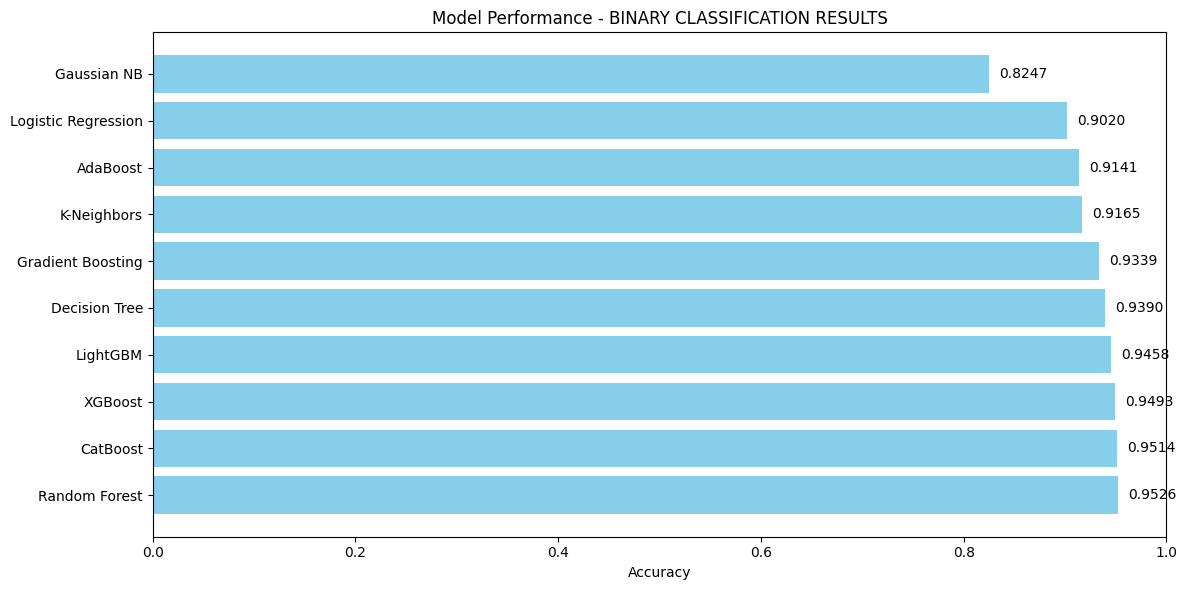

NameError: name 'results_multi' is not defined

In [14]:
def display_results(results_dict, title):
    """Display results in a clean format"""
    print(f"\n{'='*80}")
    print(f"📊 {title}")
    print(f"{'='*80}")
    
    if not results_dict:
        print("No results to display")
        return
    
    results_list = []
    for model_name, metrics in results_dict.items():
        if metrics is not None:
            results_list.append({
                'Model': model_name,
                'Accuracy': f"{metrics['accuracy']:.4f}",
                'F1-Score': f"{metrics['f1_score']:.4f}",
                'AUC-ROC': f"{metrics['auc_roc']:.4f}"
            })
    
    if results_list:
        results_df = pd.DataFrame(results_list)
        results_df = results_df.sort_values('Accuracy', ascending=False)
        print(results_df.to_string(index=False))
        
        # Plot results
        plt.figure(figsize=(12, 6))
        models = results_df['Model']
        accuracy = pd.to_numeric(results_df['Accuracy'])
        
        plt.barh(models, accuracy, color='skyblue')
        plt.xlabel('Accuracy')
        plt.title(f'Model Performance - {title}')
        plt.xlim(0, 1)
        for i, v in enumerate(accuracy):
            plt.text(v + 0.01, i, f'{v:.4f}', va='center')
        plt.tight_layout()
        plt.show()
    else:
        print("No successful model runs")

# Display results
display_results(results_binary, "BINARY CLASSIFICATION RESULTS")
display_results(results_multi, "MULTICLASS CLASSIFICATION RESULTS")

#### Visualize Model Performance


In [ ]:
def plot_model_comparison(results_df, title):
    """Plot model performance comparison"""
    plt.figure(figsize=(15, 8))
    
    # Set positions
    x = np.arange(len(results_df))
    width = 0.25
    
    # Create bars
    plt.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
    plt.bar(x, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
    plt.bar(x + width, results_df['AUC-ROC'], width, label='AUC-ROC', alpha=0.8)
    
    # Customize plot
    plt.xlabel('Models')
    plt.ylabel('Scores')
    plt.title(f'Model Performance Comparison - {title}')
    plt.xticks(x, results_df['Model'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot comparisons
plot_model_comparison(binary_results_df, "Binary Classification")
plot_model_comparison(multi_results_df, "Multiclass Classification")

#### Confusion Matrix for Best Models


In [ ]:
def plot_best_model_confusion_matrix(results_dict, models_dict, X_test, y_test, title):
    """Plot confusion matrix for the best performing model"""
    if not results_dict:
        print(f"No results available for {title}")
        return
    
    # Find best model
    best_model_name = None
    best_accuracy = 0
    
    for model_name, metrics in results_dict.items():
        if metrics is not None and metrics['accuracy'] > best_accuracy:
            best_accuracy = metrics['accuracy']
            best_model_name = model_name
    
    if best_model_name and best_model_name in models_dict:
        best_model = models_dict[best_model_name]
        
        # Make predictions
        y_pred = best_model.predict(X_test)
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        
        if title == "BINARY CLASSIFICATION":
            labels = ['Normal', 'Attack']
        else:
            labels = ['Normal', 'Backdoor', 'Analysis', 'Fuzzers', 'Shellcode', 
                     'Reconnaissance', 'Exploits', 'DoS', 'Worms', 'Generic']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels[:len(np.unique(y_test))], 
                   yticklabels=labels[:len(np.unique(y_test))])
        plt.title(f'Confusion Matrix - {best_model_name}\n({title})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()
        
        print(f"🏆 Best Model for {title}: {best_model_name}")
        print(f"📊 Accuracy: {best_accuracy:.4f}")
        print(f"\n📋 Classification Report:")
        print(classification_report(y_test, y_pred))
    else:
        print(f"No successful model found for {title}")

# Plot confusion matrices
plot_best_model_confusion_matrix(results_binary, models_binary, X_test_bin_scaled, y_test_bin, "BINARY CLASSIFICATION")
plot_best_model_confusion_matrix(results_multi, models_multi, X_test_multi_scaled, y_test_multi, "MULTICLASS CLASSIFICATION")

#### Feature Importance Analysis

In [ ]:
def plot_feature_importance(best_model, feature_names, title, top_n=15):
    """Plot feature importance for the best model"""
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(12, 8))
        plt.title(f'Top {top_n} Feature Importance - {title}')
        bars = plt.bar(range(top_n), importances[indices[:top_n]], color='lightcoral')
        plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
        plt.ylabel('Importance')
        plt.tight_layout()
        
        # Add value labels on bars
        for bar, importance in zip(bars, importances[indices[:top_n]]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                    f'{importance:.4f}', ha='center', va='bottom', fontsize=8)
        
        plt.show()
        
        # Print top features
        print(f"🔍 Top {top_n} Most Important Features for {title}:")
        for i in range(top_n):
            print(f"{i+1:2d}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
    else:
        print(f"Model doesn't support feature importance visualization")

# Get feature names
feature_names = X.columns.tolist()

# Plot feature importance for best binary model
if results_binary:
    best_binary_name = max([(name, metrics['accuracy']) for name, metrics in results_binary.items() if metrics is not None], 
                          key=lambda x: x[1])[0]
    best_binary_model = models_binary[best_binary_name]
    plot_feature_importance(best_binary_model, feature_names, f"Binary - {best_binary_name}")

# Plot feature importance for best multiclass model  
if results_multi:
    best_multi_name = max([(name, metrics['accuracy']) for name, metrics in results_multi.items() if metrics is not None], 
                         key=lambda x: x[1])[0]
    best_multi_model = models_multi[best_multi_name]
    plot_feature_importance(best_multi_model, feature_names, f"Multiclass - {best_multi_name}")

#### Hyperparameter Tuning for Best Model


In [ ]:
def hyperparameter_tuning_best_model(model, param_grid, X_train, y_train, X_test, y_test):
    """Perform hyperparameter tuning for the best model"""
    print(f"🔧 Performing Hyperparameter Tuning for {model.__class__.__name__}...")
    
    # Use RandomizedSearchCV for faster tuning
    random_search = RandomizedSearchCV(
        model, param_grid, n_iter=20, cv=3, scoring='accuracy', 
        n_jobs=-1, random_state=42, verbose=1
    )
    
    random_search.fit(X_train, y_train)
    
    print(f"✅ Best parameters: {random_search.best_params_}")
    print(f"✅ Best cross-validation score: {random_search.best_score_:.4f}")
    
    # Evaluate on test set
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    print(f"✅ Test set accuracy: {test_accuracy:.4f}")
    
    return best_model

# Example: Tune Random Forest if it's the best model
if best_binary_model == "Random Forest":
    rf_param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
    
    tuned_rf = hyperparameter_tuning_best_model(
        models_binary["Random Forest"], rf_param_grid,
        X_train_bin, y_train_bin, X_test_bin, y_test_bin
    )

#### Cross-Validation Performance


In [ ]:
def perform_cross_validation(models_dict, X, y, cv=5):
    """Perform cross-validation for all models"""
    cv_results = {}
    
    for name, model in models_dict.items():
        print(f"🔍 Performing {cv}-fold CV for {name}...")
        
        try:
            # Use scaled data for certain models
            if name in ["Logistic Regression", "SVM", "K-Neighbors", "Gaussian NB"]:
                X_scaled = preprocessor.fit_transform(X)
                cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
            else:
                cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
            
            cv_results[name] = {
                'mean_score': cv_scores.mean(),
                'std_score': cv_scores.std(),
                'all_scores': cv_scores
            }
            
            print(f"✅ {name} - Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
            
        except Exception as e:
            print(f"❌ CV failed for {name}: {str(e)}")
            cv_results[name] = None
    
    return cv_results

# Perform cross-validation for binary classification
print("🔍 CROSS-VALIDATION RESULTS - BINARY CLASSIFICATION")
cv_results_binary = perform_cross_validation(models_binary, X, y_binary)

# Perform cross-validation for multiclass classification
print("\n🔍 CROSS-VALIDATION RESULTS - MULTICLASS CLASSIFICATION")
cv_results_multi = perform_cross_validation(models_multi, X, y_multiclass)

#### Model Persistence - Save Best Models


In [ ]:
import joblib
import pickle
import os

def save_best_models(results_binary, results_multi, models_binary, models_multi, preprocessor, feature_names):
    """Save the best models and preprocessing objects"""
    
    # Create directory
    os.makedirs('saved_models', exist_ok=True)
    
    # Save best binary model
    if results_binary:
        best_binary_name = max([(name, metrics['accuracy']) for name, metrics in results_binary.items() if metrics is not None], 
                              key=lambda x: x[1])[0]
        best_binary_model = models_binary[best_binary_name]
        joblib.dump(best_binary_model, 'saved_models/best_binary_model.pkl')
        print(f"✅ Saved best binary model: {best_binary_name}")
    
    # Save best multiclass model
    if results_multi:
        best_multi_name = max([(name, metrics['accuracy']) for name, metrics in results_multi.items() if metrics is not None], 
                             key=lambda x: x[1])[0]
        best_multi_model = models_multi[best_multi_name]
        joblib.dump(best_multi_model, 'saved_models/best_multiclass_model.pkl')
        print(f"✅ Saved best multiclass model: {best_multi_name}")
    
    # Save preprocessor
    joblib.dump(preprocessor, 'saved_models/preprocessor.pkl')
    print("✅ Saved preprocessor")
    
    # Save feature names
    with open('saved_models/feature_names.pkl', 'wb') as f:
        pickle.dump(feature_names, f)
    print("✅ Saved feature names")
    
    print("\n🎯 Models saved in 'saved_models/' directory")

# Save models
save_best_models(results_binary, results_multi, models_binary, models_multi, preprocessor, feature_names)

#### Final Performance Summary


In [ ]:
print("🎯 FINAL TRAINING SUMMARY")

print(f"\n📊 DATASET STATISTICS:")
print(f"   Total samples: {len(df)}")
print(f"   Features: {X.shape[1]}")
print(f"   Normal traffic: {len(df[df['label'] == 0])} ({len(df[df['label'] == 0])/len(df)*100:.2f}%)")
print(f"   Attack traffic: {len(df[df['label'] == 1])} ({len(df[df['label'] == 1])/len(df)*100:.2f}%)")

if results_binary:
    best_binary = max([(name, metrics['accuracy']) for name, metrics in results_binary.items() if metrics is not None], 
                     key=lambda x: x[1])
    print(f"\n🏆 BEST BINARY CLASSIFICATION MODEL: {best_binary[0]}")
    print(f"   Accuracy: {best_binary[1]:.4f}")

if results_multi:
    best_multi = max([(name, metrics['accuracy']) for name, metrics in results_multi.items() if metrics is not None], 
                    key=lambda x: x[1])
    print(f"\n🏆 BEST MULTICLASS CLASSIFICATION MODEL: {best_multi[0]}")
    print(f"   Accuracy: {best_multi[1]:.4f}")

print(f"\n💾 MODELS SAVED:")
print("   ✅ Best binary classification model")
print("   ✅ Best multiclass classification model") 
print("   ✅ Preprocessor")
print("   ✅ Feature names")

print(f"\n🚀 MODEL TRAINING COMPLETED SUCCESSFULLY!")

#### Model Deployment Ready Function


In [ ]:
def predict_network_traffic(features, model_type='binary'):
    """
    Function to predict network traffic (ready for deployment)
    
    Parameters:
    features: array-like, shape (n_samples, n_features)
    model_type: 'binary' or 'multiclass'
    
    Returns:
    predictions: array, shape (n_samples,)
    """
    try:
        # Load preprocessor and model
        preprocessor = joblib.load('saved_models/preprocessor.pkl')
        
        if model_type == 'binary':
            model = joblib.load('saved_models/best_binary_model.pkl')
        else:
            model = joblib.load('saved_models/best_multiclass_model.pkl')
        
        # Preprocess features
        features_scaled = preprocessor.transform(features)
        
        # Make predictions
        predictions = model.predict(features_scaled)
        
        return predictions
        
    except Exception as e:
        print(f"❌ Prediction error: {str(e)}")
        return None

print("✅ Model training completed successfully!")
print("🚀 Models are ready for deployment!")